In [62]:
import pandas as pd
import numpy as np

merged = pd.read_parquet('/Users/shreya/Documents/College/Sem 5/ML/Lab/GridSense/data/processed/merged.parquet')
merged_encoded = pd.get_dummies(merged, columns=['location'], drop_first=True)

feature_cols = ['temperature', 'humidity', 'hour', 'day_of_week', 'month', 
                 'is_holiday', 'historical_avg_load','year'] + \
                [c for c in merged_encoded.columns if c.startswith('location_')]

X = merged_encoded[feature_cols]
y = merged_encoded['demand_gw']

merged_encoded = merged_encoded.sort_values('datetime')
split_idx = int(len(merged_encoded) * 0.85)

train_idx = merged_encoded.index[:split_idx]
test_idx = merged_encoded.index[split_idx:]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

X_test_with_meta = merged.loc[test_idx, ['location', 'datetime']].copy()
X_test_with_meta['actual'] = y_test.values

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")

Train size: 238312, Test size: 42056


In [63]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42
)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, xgb_preds)
rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print(f"XGBoost — MAE: {mae:.2f} GW, RMSE: {rmse:.2f} GW")

X_test_with_meta['xgb_predicted'] = xgb_preds
X_test_with_meta['xgb_abs_error'] = (X_test_with_meta['actual'] - X_test_with_meta['xgb_predicted']).abs()
X_test_with_meta['xgb_pct_error'] = (X_test_with_meta['xgb_abs_error'] / X_test_with_meta['actual']) * 100

print(X_test_with_meta.groupby('location')['xgb_pct_error'].mean().sort_values())

XGBoost — MAE: 4.38 GW, RMSE: 6.82 GW
location
National          6.405515
Western           7.546795
Eastern           7.635291
Southern          7.734964
Northern          7.974002
North-Eastern    17.604433
Name: xgb_pct_error, dtype: float64


In [64]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(xgb_model, 'models/xgb_demand_model.joblib')
joblib.dump(feature_cols, 'models/feature_cols.joblib')  # save this too — your FastAPI backend needs to know exact column order later

['models/feature_cols.joblib']

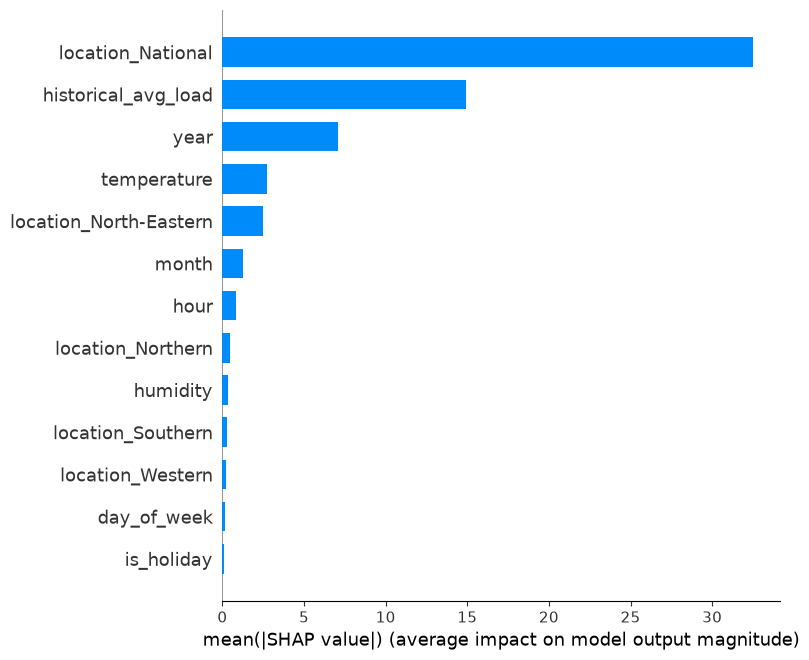

In [65]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

# global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_test, plot_type='bar')

In [66]:
# ## SHAP including location (raw)
# Location dominates due to scale differences across regions — not a useful
# signal for the explanation panel since the user already selected location.
# pick one row to explain, e.g. the first test row
row_idx = 0
row_shap = shap_values[row_idx]

# convert to contribution percentages, matching your API contract shape
feature_contributions = pd.Series(row_shap, index=feature_cols).abs()
feature_contributions_pct = (feature_contributions / feature_contributions.sum() * 100).sort_values(ascending=False)
print(feature_contributions_pct.head(10))

location_National         54.875553
year                      17.216726
historical_avg_load       10.167100
location_North-Eastern     4.359710
hour                       3.563277
temperature                3.404085
location_Southern          2.856549
location_Northern          2.324543
day_of_week                0.505443
month                      0.321543
dtype: float32


In [67]:
## SHAP excluding location (used for /explain endpoint)
# This is the breakdown actually shown to the user — drivers *within* the
# selected location's forecast.
# recompute contribution %, excluding location_* columns from the display
non_location_features = [c for c in feature_cols if not c.startswith('location_')]

row_shap_filtered = pd.Series(shap_values[row_idx], index=feature_cols)[non_location_features].abs()
row_shap_pct = (row_shap_filtered / row_shap_filtered.sum() * 100).sort_values(ascending=False)
print(row_shap_pct)

year                   48.692467
historical_avg_load    28.754660
hour                   10.077684
temperature             9.627456
day_of_week             1.429496
month                   0.909390
is_holiday              0.348312
humidity                0.160535
dtype: float32


In [68]:
def get_explanation(row_features_df, model, explainer, feature_cols, non_location_features, top_n=5):
    """
    row_features_df: single-row DataFrame with the same columns as X_train,
    in the same order (use feature_cols to enforce this)
    """
    shap_vals = explainer.shap_values(row_features_df[feature_cols])[0]
    contributions = pd.Series(shap_vals, index=feature_cols)[non_location_features].abs()
    contributions_pct = (contributions / contributions.sum() * 100).sort_values(ascending=False)
    return contributions_pct.head(top_n).to_dict()

# test it works on an arbitrary row, not just row_idx=0
test_row = X_test.iloc[[5]]
print(get_explanation(test_row, xgb_model, explainer, feature_cols, non_location_features))

{'year': 53.88600158691406, 'historical_avg_load': 23.5753231048584, 'hour': 10.212691307067871, 'temperature': 8.515934944152832, 'month': 1.805538535118103}


In [69]:
def get_whatif_prediction(row_features_df, model, feature_cols, changed_feature, delta):
    """
    row_features_df: single-row DataFrame, same columns/order as X_train
    changed_feature: e.g. 'temperature'
    delta: e.g. +4
    """
    modified_row = row_features_df.copy()
    modified_row[changed_feature] = modified_row[changed_feature] + delta
    
    original_pred = model.predict(row_features_df[feature_cols])[0]
    new_pred = model.predict(modified_row[feature_cols])[0]
    
    return {
        'original_demand_gw': float(original_pred),
        'new_demand_gw': float(new_pred),
        'change_gw': float(new_pred - original_pred)
    }

# test it
test_row = X_test.iloc[[5]]
print(get_whatif_prediction(test_row, xgb_model, feature_cols, 'temperature', 4))

{'original_demand_gw': 43.45124435424805, 'new_demand_gw': 47.533203125, 'change_gw': 4.081958770751953}


In [70]:
# build the "typical" baseline per location/hour/day_of_week from training data
typical_stats = (
    merged.loc[train_idx]
    .groupby(['location', 'hour', 'day_of_week'])['demand_gw']
    .agg(['mean', 'std'])
    .reset_index()
)

def flag_anomalies(predictions_df, typical_stats, threshold=2):
    """
    predictions_df: DataFrame with columns location, hour, day_of_week, predicted_demand_gw
    """
    merged_check = predictions_df.merge(typical_stats, on=['location', 'hour', 'day_of_week'], how='left')
    merged_check['z_score'] = (merged_check['predicted_demand_gw'] - merged_check['mean']) / merged_check['std']
    merged_check['is_anomaly'] = merged_check['z_score'].abs() > threshold
    return merged_check[['location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']]

In [71]:
# build a small test set of "predictions" to check against
test_sample = merged.loc[test_idx, ['location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds  # from your earlier XGBoost predictions

anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)
print(f"Anomalies flagged: {anomaly_results['is_anomaly'].sum()} out of {len(anomaly_results)}")
anomaly_results[anomaly_results['is_anomaly']].head(10)

Anomalies flagged: 4736 out of 42056


,location,hour,day_of_week,predicted_demand_gw,z_score,is_anomaly
7,North-Eastern,23,3,3.338481,3.293278,True
8,North-Eastern,0,4,2.803751,2.302741,True
35,North-Eastern,4,4,2.367507,2.079382,True
43,North-Eastern,5,4,2.378539,2.412890,True
54,Eastern,7,4,22.677181,2.132403,True
60,Eastern,8,4,23.216253,2.182445,True
80,North-Eastern,12,4,2.719595,2.920009,True
86,North-Eastern,13,4,2.832845,3.180104,True
111,Eastern,17,4,23.271526,2.024522,True
124,Eastern,19,4,26.370014,2.275809,True


In [72]:
test_sample = merged.loc[test_idx, ['datetime', 'location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds

anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)

In [73]:
# 1. redefine the function (make sure this cell actually executes)
def flag_anomalies(predictions_df, typical_stats, threshold=2):
    merged_check = predictions_df.merge(typical_stats, on=['location', 'hour', 'day_of_week'], how='left')
    merged_check['z_score'] = (merged_check['predicted_demand_gw'] - merged_check['mean']) / merged_check['std']
    merged_check['is_anomaly'] = merged_check['z_score'].abs() > threshold
    return merged_check[['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']]

In [74]:
# 2. rebuild test_sample WITH datetime included
test_sample = merged.loc[test_idx, ['datetime', 'location', 'hour', 'day_of_week']].copy()
test_sample['predicted_demand_gw'] = xgb_preds

print(test_sample.columns.tolist())  # sanity check — should show datetime

['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw']


In [75]:
# 3. now call it
anomaly_results = flag_anomalies(test_sample, typical_stats, threshold=2)
print(anomaly_results.columns.tolist())  # confirm datetime made it through

['datetime', 'location', 'hour', 'day_of_week', 'predicted_demand_gw', 'z_score', 'is_anomaly']


In [76]:
anomalies_only = anomaly_results[anomaly_results['is_anomaly']]
print(anomalies_only[anomalies_only['location']=='North-Eastern']['datetime'].dt.date.value_counts().head(10))
print(anomalies_only['location'].value_counts())

datetime
2023-09-06    24
2023-09-10    24
2023-09-16    24
2023-08-17    24
2023-08-01    24
2023-09-01    24
2023-09-29    24
2023-09-05    24
2023-09-09    23
2023-09-14    23
Name: count, dtype: int64
location
North-Eastern    2812
Southern          635
Eastern           539
Northern          393
Western           180
National          177
Name: count, dtype: int64


In [77]:
train_df = merged.loc[train_idx]
test_df = merged.loc[test_idx]

ne_train_mean = train_df[train_df['location']=='North-Eastern']['demand_gw'].mean()
ne_test_mean = test_df[test_df['location']=='North-Eastern']['demand_gw'].mean()
print(f"NE train mean: {ne_train_mean:.2f} GW, NE test mean: {ne_test_mean:.2f} GW")

NE train mean: 1.98 GW, NE test mean: 2.19 GW


In [78]:
avg_std_by_location = typical_stats.groupby('location')['std'].mean().sort_values()
print(avg_std_by_location)

location
North-Eastern     0.312568
Eastern           3.093827
Southern          5.558022
Western           6.724148
Northern          9.554748
National         18.912437
Name: std, dtype: float64


In [79]:
print(feature_cols)
print(non_location_features)

['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_holiday', 'historical_avg_load', 'year', 'location_National', 'location_North-Eastern', 'location_Northern', 'location_Southern', 'location_Western']
['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_holiday', 'historical_avg_load', 'year']


In [80]:
import joblib

joblib.dump(xgb_model, 'models/xgb_demand_model.joblib')
joblib.dump(explainer, 'models/shap_explainer.joblib')
joblib.dump(feature_cols, 'models/feature_cols.joblib')
joblib.dump(non_location_features, 'models/non_location_features.joblib')
typical_stats.to_parquet('/Users/shreya/Documents/College/Sem 5/ML/Lab/GridSense/data/processed/typical_stats.parquet', index=False)

In [81]:
import pandas as pd
merged = pd.read_parquet('../data/processed/merged.parquet')  # adjust path if needed based on notebook location
merged[(merged['location'] == 'Northern') & (merged['datetime'] == '2024-03-15 14:00:00')]

,datetime,location,demand_gw,temperature,humidity,hour,day_of_week,month,year,is_holiday,historical_avg_load
92342,2024-03-15 14:00:00,Northern,52.19856,27.2,23,14,4,3,2024,0,50.15419


In [82]:
typical_stats = pd.read_parquet('../data/processed/typical_stats.parquet')
typical_stats[(typical_stats['location'] == 'Northern') & (typical_stats['hour'] == 14) & (typical_stats['day_of_week'] == 4)]

,location,hour,day_of_week,mean,std
606,Northern,14,4,48.731403,10.022762


In [83]:
row = pd.DataFrame([{
    "temperature": 27.2,
    "humidity": 23,
    "hour": 14,
    "day_of_week": 4,
    "month": 3,
    "is_holiday": 0,
    "historical_avg_load": 48.731403,
    "location": "Northern",
}])
row_encoded = pd.get_dummies(row)
print(row_encoded.columns.tolist())
print()
print(feature_cols)  # your saved feature_cols.joblib

['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_holiday', 'historical_avg_load', 'location_Northern']

['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_holiday', 'historical_avg_load', 'year', 'location_National', 'location_North-Eastern', 'location_Northern', 'location_Southern', 'location_Western']


In [84]:
timestamps = [
    ("Western", "2024-01-10 09:00:00"),
    ("Southern", "2024-02-20 19:00:00"),
    ("Eastern", "2023-12-05 06:00:00"),
    ("North-Eastern", "2024-03-01 12:00:00"),
]

for loc, ts in timestamps:
    row = merged[(merged['location'] == loc) & (merged['datetime'] == ts)]
    print(loc, ts, row['demand_gw'].values)

Western 2024-01-10 09:00:00 [68.11169]
Southern 2024-02-20 19:00:00 [50.61466]
Eastern 2023-12-05 06:00:00 [16.85682]
North-Eastern 2024-03-01 12:00:00 [1.97724]


In [85]:
merged['year'] = pd.to_datetime(merged['datetime']).dt.year
print(merged.groupby('year')['demand_gw'].mean())

year
2019    48.942924
2020    47.331517
2021    52.089711
2022    56.293182
2023    60.262623
2024    61.264379
Name: demand_gw, dtype: float64


In [86]:
print(feature_cols) 


['temperature', 'humidity', 'hour', 'day_of_week', 'month', 'is_holiday', 'historical_avg_load', 'year', 'location_National', 'location_North-Eastern', 'location_Northern', 'location_Southern', 'location_Western']
